# Epeak-Eiso.ipynb for GW Counterparts (SGRBs)

In [33]:
import numpy as np
import h5py
from astropy.cosmology import LambdaCDM
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reading data
with h5py.File('nsns_population_joan.hdf5', 'r') as table:
    z = table['z'][()]
    Epeak = np.log10(table['Epeak'][()])
    Epeak_err = 0.1 * Epeak # 10% errors on Epeak
    linear_err = 0.05*table['Epeak'][()]
    Epeak_err = linear_err / (table['Epeak'][()] + np.log(10))

    original_Eiso = np.log10(table['Eiso'][()])

nan_mask1 = np.isnan(original_Eiso)
nan_mask2 = np.isnan(Epeak)
combined_nan_mask = nan_mask1 | nan_mask2

inf_mask1 = np.isinf(original_Eiso)
inf_mask2 = np.isinf(Epeak)
combined_inf_mask = inf_mask1 | inf_mask2

outliner_mask = [val<40 for val in original_Eiso]
# for i, x in enumerate(outliner_mask):
#     if x==True:
#         print(i,x)

total_combined_mask = combined_nan_mask | combined_inf_mask | outliner_mask
inverse_mask = ~total_combined_mask

z = z[inverse_mask]
original_Eiso = original_Eiso[inverse_mask]
Epeak = Epeak[inverse_mask]
Epeak_err = Epeak_err[inverse_mask]

sorting_indices = np.argsort(original_Eiso)

z = z[sorting_indices]
original_Eiso = original_Eiso[sorting_indices]
Epeak = Epeak[sorting_indices]
Epeak_err = Epeak_err[sorting_indices]

/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_11162/3860847473.py:16: RuntimeWarning: divide by zero encountered in log10
  original_Eiso = np.log10(table['Eiso'][()])
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_11162/3860847473.py:16: RuntimeWarning: invalid value encountered in log10
  original_Eiso = np.log10(table['Eiso'][()])


In [38]:
# Using only first 100 data points
# increasing the number of points makes the contours bigger
print(len(z))
original_Eiso = original_Eiso[0:99]
Epeak = Epeak[0:99]
Epeak_bc = Epeak_bc[0:99]
Epeak_err = Epeak_err[0:99]
z = z[0:99]
print(len(z))

original_Eiso_bc = original_Eiso - np.mean(original_Eiso)
ycm = np.mean(Epeak)
Epeak_bc = Epeak - ycm

print("MinMax redshift: ", np.min(z), np.max(z))

999
99
MinMax redshift:  0.07954538167150245 0.9790993368540551


Text(0.5, 1.0, 'Epeak-Eiso correlation for SGRBs')

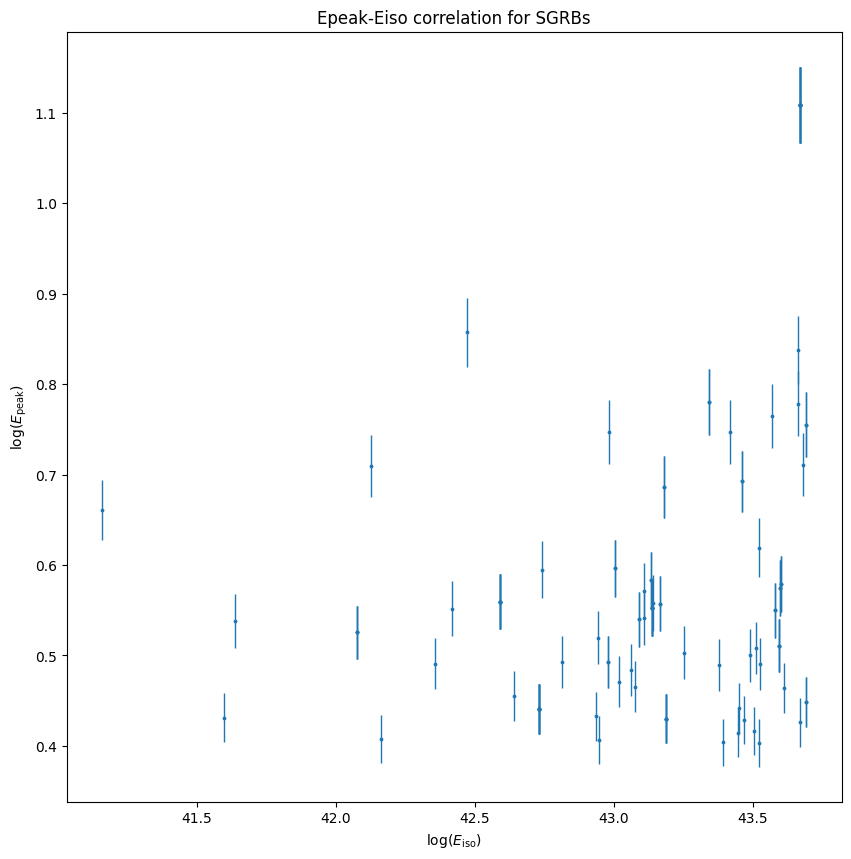

In [39]:
plt.figure(figsize=(10,10))
plt.scatter(original_Eiso, Epeak, s=3)
plt.errorbar(original_Eiso, Epeak, yerr=Epeak_err, fmt='none', elinewidth=1)
plt.xlabel(r'$\log(E_\text{iso})$'); plt.ylabel(r'$\log(E_\text{peak})$'); plt.title('Epeak-Eiso correlation for SGRBs')

In [40]:
# computing correlations
# we have:
# original_Eiso original_Eiso_bc
# Epeak Epeak_bc ycm Epeak_err(synthetic)
# z

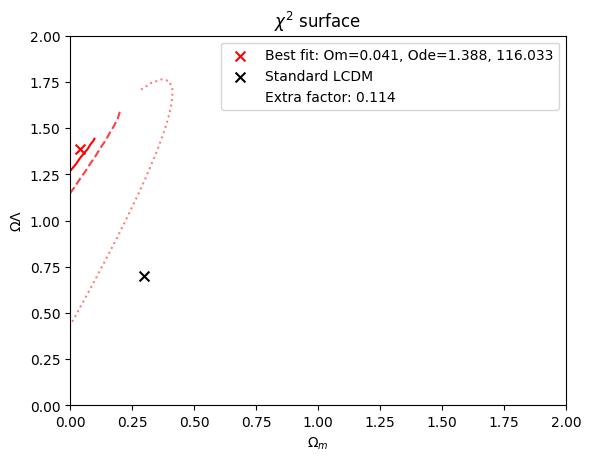

<Figure size 640x480 with 0 Axes>

In [42]:
Om = np.linspace(0.0, 2.0, 50)
Ode = np.linspace(0.0, 2.0, 50)

factor = 1.30
extra_err = np.log10(factor)

standard_cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
standard_dl = standard_cosmo.luminosity_distance(z)

chi_surface = np.zeros([len(Om), len(Ode)])
a = np.zeros([len(Om), len(Ode)])
b = np.zeros([len(Om), len(Ode)])
mask = np.zeros([len(Om), len(Ode)])

def model(x, p1, p2):
    return p1*x + p2


for i in tqdm(range(len(Om)), desc="Calculating χ² surface", leave=False):
    for j in range(len(Ode)):
        cosmo = LambdaCDM(H0=70, Om0=Om[i], Ode0=Ode[j])
        dl = cosmo.luminosity_distance(z)

        Eiso = 2*np.log10(dl/standard_dl) + original_Eiso
        Eiso_bc = Eiso - (np.sum(Eiso)/len(Eiso))

        if np.isnan(Eiso).any():
            a[i, j], b[i, j] = -1e4, -1e4
            chi_surface[i, j] = 1e4
            mask[i,j] = True
            continue

        total_err = Epeak_err + extra_err

        popt, pcov = curve_fit(model, Eiso_bc, Epeak_bc, sigma=total_err, p0=[0.5, 0.0], bounds=([-10.0, -10.0], [10.0, 10.0]))
        a[i,j], b[i,j] = popt
        residuals = Epeak_bc - model(Eiso_bc, *popt)
        dof = len(Eiso_bc)-2
        chi_surface[i, j] = np.sum((residuals / total_err) ** 2)#/dof

masked_chi_surface = np.ma.array(chi_surface, mask=mask)

min_chi = np.nanmin(masked_chi_surface)
i1, i2 = np.unravel_index(np.nanargmin(masked_chi_surface), masked_chi_surface.shape)
Om_fit, Ode_fit = Om[i1], Ode[i2]

# Plotting
plt.figure()
#plt.contourf(Om, Ode, masked_chi_surface.T, levels=50)
plt.contour(Om, Ode, masked_chi_surface.T, levels=[min_chi+2.3, min_chi+4.61, min_chi+9.21], colors='r', alpha=[1.0, 0.75, 0.5], linestyles=['solid','dashed','dotted']) # 68, 95 and 99.7 percent confidence levels for two parameters
plt.scatter(Om_fit, Ode_fit, c='r', s=50, marker='x', label=f'Best fit: Om={Om_fit:.3f}, Ode={Ode_fit:.3f}, {min_chi:.3f}')
#plt.colorbar(label='chi2')
plt.scatter(0.3, 0.7, c='black', s=50, marker='x', label=f'Standard LCDM')
plt.scatter(-1, -1, alpha=0.0, label=f'Extra factor: {extra_err:.3f}')
plt.xlim(0.0,2.0); plt.ylim(0.0, 2.0)
plt.xlabel(r'$\Omega_m$')
plt.ylabel(r'$\Omega\Lambda$')
plt.title(r'$\chi^2$ surface')
plt.legend()
plt.show()
plt.savefig('SGRBX2.png')

np.save('SGRB_chi_surface.npy', chi_surface)
np.save('SGRB_mask.npy', mask)

# Single Correlation

In [2]:
factor = 1
extra_err = np.log10(factor)
total_err = Epeak_err + extra_err
standard_cosmo = LambdaCDM(H0=70, Om0=1.0, Ode0=1.0)
standard_dl = standard_cosmo.luminosity_distance(z).value

def linear(x, p1, p2):
    return p1*x + p2

def model(x, p1, p2):
    return p1**x + p2

cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.3)
dl = cosmo.luminosity_distance(z).value


# print('z\tstddl\tdl\tEiso\tEiso_bc\tmean')
Eiso = 2*np.log10(dl/standard_dl) + original_Eiso
xcm = np.mean(Eiso)
Eiso_bc = Eiso - xcm
# for i in range(len(z[0:10])):
#     print(z[i],standard_dl[i], dl[i], original_Eiso[i], Eiso[i], Eiso_bc[i], np.mean(Eiso))

if np.isnan(Eiso_bc).any():
    print('WRONG; WRONG!')

popt_l, pcov_l = curve_fit(linear, Eiso_bc, Epeak_bc, p0=[0.5, 0.0], bounds=([-10.0, -10.0], [10.0, 10.0]), sigma=total_err) # linear
popt, pcov = curve_fit(model, Eiso_bc, Epeak_bc, p0=[0.5, 0.0], bounds=([-100.0, -100.0], [100.0, 100.0]), sigma=total_err)
al, bl = popt_l
a_fit, b_fit = popt
residuals = Epeak_bc - linear(Eiso_bc, *popt_l)
dof = len(Eiso_bc)-2
chi_value = np.sum((residuals / total_err) ** 2)/dof
print(a_fit, b_fit, chi_value)

1.2723567049531654 -1.065850048858061 25.32869608611239


1047 1047
46.32374021485291 0.8532573962396564


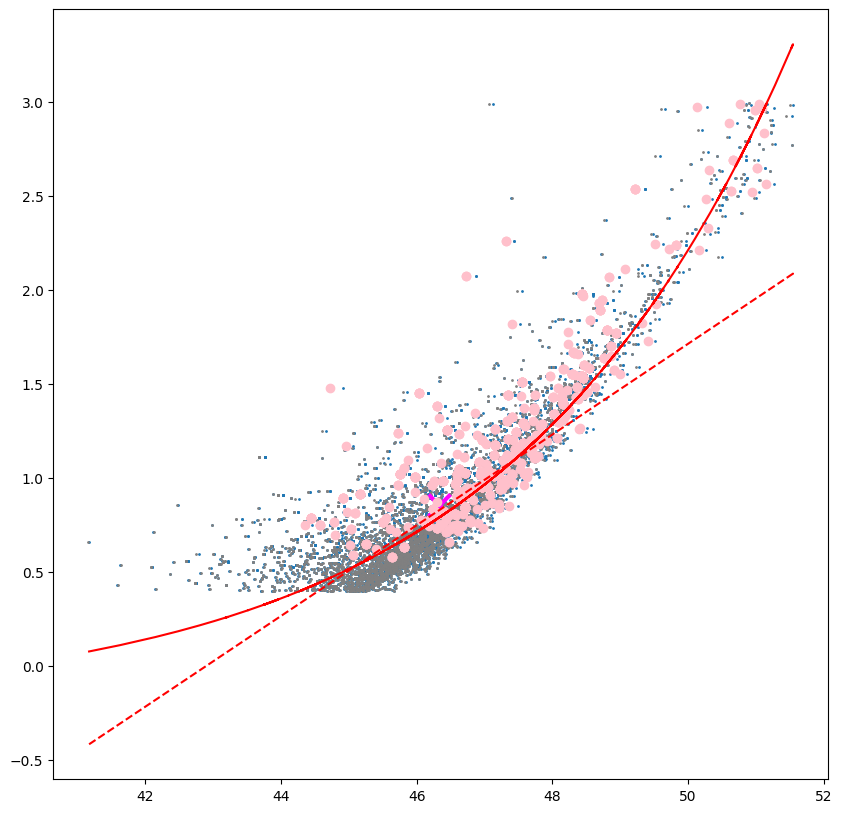

In [3]:
plt.figure(figsize=(10,10))
plt.scatter(Eiso, Epeak, s=1)
#plt.errorbar(Eiso, Epeak, yerr=Epeak_err, fmt='none', elinewidth=1)
plt.plot(Eiso, model(Eiso_bc, a_fit, b_fit+ycm), c='r')
plt.scatter(original_Eiso, Epeak, s=1, c='gray')
plt.plot(Eiso, linear(Eiso_bc, al, bl+ycm), c='r', linestyle='--')
plt.scatter(xcm, ycm, marker='x', color='magenta', label='Barycenter', linewidths=3, s=250)
plt.scatter(original_Eiso[z>1.0], Epeak[z>1.0], c='pink')
print(len(original_Eiso[z>1.0]), len(Epeak[z>1.0]))
print(xcm, ycm)

# Multiple Cosmologies

In [4]:
factor = 15
extra_err = np.log10(factor)
total_err = Epeak_err + extra_err
standard_cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)
standard_dl = standard_cosmo.luminosity_distance(z).value

def model(x, p1, p2):
    #return p1**x + p2
    return p1*x +p2

Om = np.linspace(0.0, 2.0, 25)
Ode = np.linspace(0.0, 2.0, 25)

chi_surface = np.zeros([len(Om), len(Ode)])
a = np.zeros([len(Om), len(Ode)])
b = np.zeros([len(Om), len(Ode)])
mask = np.zeros([len(Om), len(Ode)])

for i in range(len(Om)):
    for j in range(len(Ode)):
        cosmo = LambdaCDM(H0=70, Om0=Om[i], Ode0=Ode[j])
        dl = cosmo.luminosity_distance(z).value

        Eiso = 2*np.log10(dl/standard_dl) + original_Eiso
        xcm = np.mean(Eiso)
        Eiso_bc = Eiso - np.mean(Eiso)

        if np.isnan(Eiso_bc).any():
            chi_surface[i,j]=1e4
            mask[i,j]=True
            continue

        popt, pcov = curve_fit(model, Eiso_bc, Epeak_bc, p0=[0.5, 0.0], bounds=([-100.0, -100.0], [100.0, 100.0])) #, sigma=total_err
        a[i,j], b[i,j] = popt
        residuals = Epeak_bc - model(Eiso_bc, *popt)
        dof = len(Eiso_bc)-2
        chi_surface[i,j] = np.sum((residuals / total_err) ** 2)/dof

        # n1 = np.random.randint(0,625)
        # if n1 in [234, 157, 347]:
        #     plt.figure()
        #     plt.scatter(original_Eiso, Epeak, s=1, color='grey', alpha=0.8)
        #     plt.scatter(Eiso, Epeak, s=1)
        #     plt.plot(Eiso, model(Eiso_bc, a[i,j], b[i,j]+ycm), c='r', label=f'fit: a={a[i,j]:.3f}, b={b[i,j]:.3f}, X={chi_surface[i,j]:.3f}')
        #     plt.scatter(xcm, ycm, color='magenta', marker='x', label='Barycenter')
        #     plt.legend()
        #     #plt.xlim(41, 52)
        #     plt.ylim(0.0, 3.5)
        #     plt.show()
        #     plt.close()

/Users/joanalnu/opt/anaconda3/envs/grbcosmo/lib/python3.13/site-packages/astropy/cosmology/_src/flrw/base.py:1179: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return quad(self._inv_efunc_scalar, z1, z2, args=self._inv_efunc_scalar_args)[0]
/Users/joanalnu/opt/anaconda3/envs/grbcosmo/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2623: RuntimeWarning: invalid value encountered in _integral_comoving_distance_z1z2_scalar (vectorized)
  outputs = ufunc(*args, out=...)
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_11162/2642159971.py:24: RuntimeWarning: invalid value encountered in log10
  Eiso = 2*np.log10(dl/standard_dl) + original_Eiso
/Users/joanalnu/opt/anaconda3/envs/grbcosmo/lib/python3.13/site-packages/astropy/cosmology/_src/flrw/base.py:1179: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increas

In [5]:
masked_chi_surface = np.ma.array(chi_surface, mask=mask)

min_chi = np.min(masked_chi_surface)
i1, i2 = np.unravel_index(np.argmin(masked_chi_surface), masked_chi_surface.shape)
Om_fit, Ode_fit = Om[i1], Ode[i2]
print(Om_fit, Ode_fit, min_chi)

plt.figure()
#plt.contourf(Om, Ode, chi_surface.T, cmap='plasma', alpha=0.3)
plt.contourf(Om, Ode, masked_chi_surface.T, cmap='plasma')
plt.contour(Om, Ode, masked_chi_surface.T, levels=[min_chi+2.3, min_chi+4.61, min_chi+9.21], colors='lime')
plt.scatter(Om_fit, Ode_fit, c='b', marker='x', label=f'Fit: Om={Om_fit:.3f}, Ode={Ode_fit:.3f} chi={min_chi:.3f}')

np.save('SGRB_chi_surface.npy', chi_surface)
np.save('SGRB_mask.npy', mask)

0.0 1.0833333333333333 0.024674115855139643
